# Preprocessing

In [186]:
# Import here Needed Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
# Data Loading
df = pd.read_csv('/content/Mart_Sales.csv')

In [188]:
# show first and last 5 rows
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [189]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [190]:
# shape of the data
df.shape

(8523, 12)

In [191]:
# Describe
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# Handling missing values

Before doing anything, find out where the "missing" in the data are

In [192]:
# check missing values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


okay now we found number of missing values

- <b> features to be removed ---> 80%  is nan
- <b> features to filled --------> less than 80 %
- <b> observation to be removed --> less than 3%

In [193]:
# percentage of the missing values
null_perc = df.isna().sum()/df.shape[0]*100
null_perc

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [194]:
# Okay both of the missing 2 columns are numerical column, Categorial so what do you think we will fill the 2 Null values columns with????
# # if null count is > 3% and < 80%  fill it by mean
# if null count is < 3% remove this row that contain this null value
def fill_missing_values(df):
  null_perc = df.isna().sum()/df.shape[0]*100
  for col in df.columns:
    if null_perc[col] >= 80:
      df.drop(col, axis=1, inplace=True)
    elif null_perc[col] > 3:
      if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
      else:
        df[col].fillna(df[col].mean(), inplace=True)
    elif null_perc[col] > 0 and null_perc[col] <= 3:
      df.dropna(subset=[col], inplace=True)
  return df

df = fill_missing_values(df)

/tmp/ipython-input-515851377.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-515851377.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [195]:
# lets check if the missing values are filled or not
df.isna().sum().sum()

np.int64(0)

In [196]:
# Okay now lets check if there is duplicates in the data
df.duplicated().sum()

np.int64(0)

# Handling outliers

know we will check for the outliers and we will trys 2 ways.

how the boxplot visualize
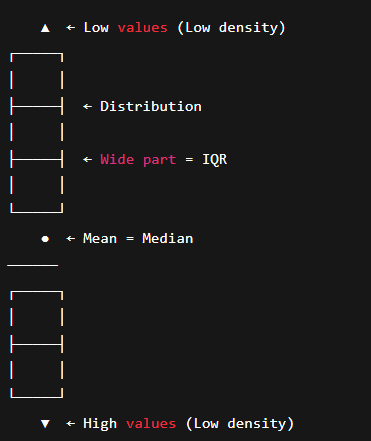

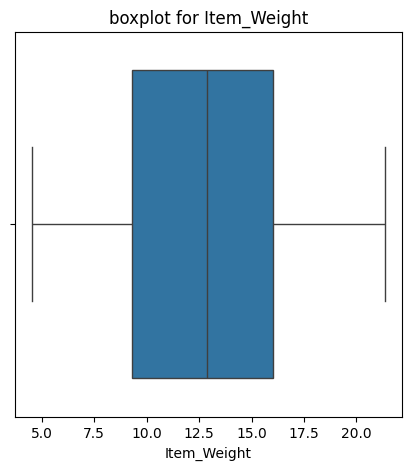

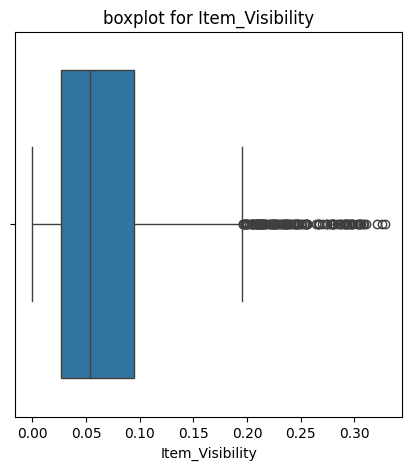

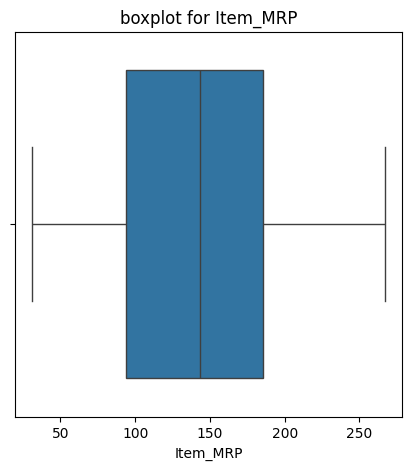

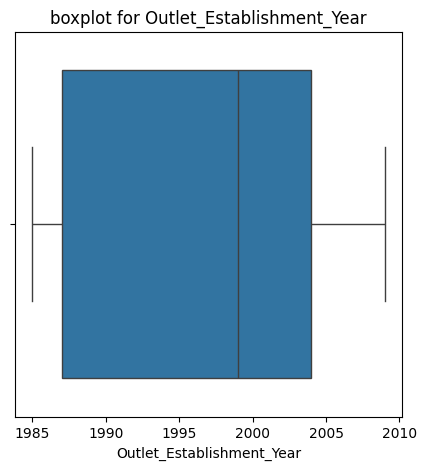

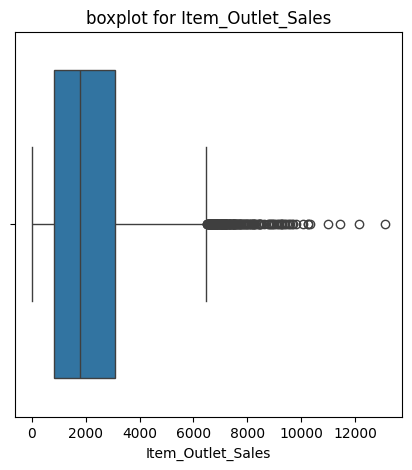

In [197]:
#Boxplot Method (Visualization)
# don't forget to make sure that while using boxplot or checking the outliers you can't pass any categorical columns

numerical_columns = ['Item_Weight','Item_Visibility','Item_MRP',
                    'Outlet_Establishment_Year','Item_Outlet_Sales']

for col in numerical_columns:
  plt.figure(figsize=(5,5))
  sns.boxplot(x=df[col])
  plt.title(f'boxplot for {col}')
  plt.show()

In [198]:
#IQR Method
def IQR_method(df,cols):
  for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{col}\nNumber of outliers: {outliers.shape[0]}")

numerical_columns = ['Item_Weight','Item_Visibility','Item_MRP',
                     'Outlet_Establishment_Year','Item_Outlet_Sales']

IQR_method(df, numerical_columns)

Item_Weight
Number of outliers: 0
Item_Visibility
Number of outliers: 144
Item_MRP
Number of outliers: 0
Outlet_Establishment_Year
Number of outliers: 0
Item_Outlet_Sales
Number of outliers: 186


now you will see 2 columns with outliers and we will try to handle oultiers in those 2 columns

In [199]:
# Handling Outliers using IQR Method
# Two ways:
# Deleting rows  --> Use when outliers % is small (<5%)
# Capping values --> Use in production to avoid data loss

oultiers_column = ['Item_Outlet_Sales','Item_Visibility']# lol you mean outlier -_-


    # CAPPING OUTLIERS (SAFE METHOD)
    # Use When:
    # - You don't want to lose data
    # - Working in production
    # - Column has important extreme values
    # df[col] = df[col].clip(lower, upper)
    # print(f"{col} cleaned using capping method")

    # DELETING OUTLIERS (WORKING)
    # Use when:
    # - Dataset is large
    # - Outliers percentage is very small
    # - Column is NOT target variable

#____# 1 method with 2 modes
def IQR_method_2m(df,cols,target,method='del'):
  for col in oultiers_column:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    if col == target:
            # Cap target, don't delete
            df[col] = df[col].clip(lower, upper)
            print(f"{col}: capped outliers (target)")
    else:
      if method == 'del':
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        print(f"{col} cleaned using deleting outliers method")
      elif method == 'Cap':
        df[col] = df[col].clip(lower, upper)
        print(f"{col} cleaned using capping method")
      else:
        raise ValueError("Method must be 'cap' or 'del'")
  return df

df = IQR_method_2m(df, oultiers_column, target='Item_Outlet_Sales', method='del')
print('Final dataset shape:', df.shape)

Item_Outlet_Sales: capped outliers (target)
Item_Visibility cleaned using deleting outliers method
Final dataset shape: (8379, 12)


# Skewness Handling


In [200]:
# N = number of rows
N = df.shape[0]

# Calculate skewness for numeric features
skewness = df[numerical_columns].skew()
skewness

,0
Item_Weight,0.089860
Item_Visibility,0.738153
Item_MRP,0.129015
Outlet_Establishment_Year,-0.414811
Item_Outlet_Sales,0.863840


In [203]:
# Apply log transformation for features with |skewness| > 1
skewed_features = skewness[abs(skewness) > 1]
print("Highly skewed features:", skewed_features.index.tolist())

# Apply log1p (log(1 + x)) to avoid log(0)
for col in skewed_features.index:
    df[col] = np.log1p(df[col])
    print(f"Applied log transform to {col}")


Highly skewed features: []


# Encoding Categorical columns

In [205]:
#Encode categorical features with label encoding
from sklearn.preprocessing import LabelEncoder

cat_cols=df.select_dtypes(include='object').columns
le=LabelEncoder()
for col in cat_cols:
  df[col]=le.fit_transform(df[col])
  print(f"{col} encoded with label encoding")

Item_Identifier encoded with label encoding
Item_Fat_Content encoded with label encoding
Item_Type encoded with label encoding
Outlet_Identifier encoded with label encoding
Outlet_Size encoded with label encoding
Outlet_Location_Type encoded with label encoding
Outlet_Type encoded with label encoding
